# Midterm EDA Project - What Determines the Spread Between Brent and WTI?

One of the most commonly studied relationships in energy finance is the spread between Brent crude and West Texas Intermediate (WTI).

Brent is the global benchmark used in Europe and much of the world, while WTI is the main benchmark in the United States. Normally they trade close to each other, but sometimes the spread widens significantly.

My project uses the FRED API to pull historical data on Brent & WTI. I use said data to analyze (through figures/statistics) how the spread changes over time and identify periods when the spread becomes unusually large.

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

# Setting up the API
First searching up the series id's related to crude oil.
FRED: fred/series/observations

In [2]:
api_key = '238320d4e8c8e060bc6d4e4ff3f660d1'
url = f'https://api.stlouisfed.org/fred/series/search?search_text=crude+oil&api_key={api_key}&file_type=json'

response = requests.get(url)
data = response.json()

data['seriess'][0:5] #see first 5

[{'id': 'DCOILWTICO',
  'realtime_start': '2026-03-19',
  'realtime_end': '2026-03-19',
  'title': 'Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma',
  'observation_start': '1986-01-02',
  'observation_end': '2026-03-16',
  'frequency': 'Daily',
  'frequency_short': 'D',
  'units': 'Dollars per Barrel',
  'units_short': '$ per Barrel',
  'seasonal_adjustment': 'Not Seasonally Adjusted',
  'seasonal_adjustment_short': 'NSA',
  'last_updated': '2026-03-18 12:32:37-05',
  'popularity': 86,
  'group_popularity': 87,
  'notes': 'Definitions, Sources and Explanatory Notes (http://www.eia.doe.gov/dnav/pet/TblDefs/pet_pri_spt_tbldef2.asp)'},
 {'id': 'MCOILWTICO',
  'realtime_start': '2026-03-19',
  'realtime_end': '2026-03-19',
  'title': 'Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma',
  'observation_start': '1986-01-01',
  'observation_end': '2026-02-01',
  'frequency': 'Monthly',
  'frequency_short': 'M',
  'units': 'Dollars per Barrel',
  'units_sh

In [3]:
api_key = '238320d4e8c8e060bc6d4e4ff3f660d1'
url = f'https://api.stlouisfed.org/fred/series/observations?series_id=DCOILWTICOA&api_key={api_key}&file_type=json'

parameters = {
    'api_key': api_key,
    'file_type': 'json',
    'series_id': 'DCOILWTICO', #Crude Oil Prices: West Texas Intermediate (WTI)
    'realtime_start': '2000-01-01',
    'realtime_end': '2026-03-09',
    'observation_start': '2000-01-02',
    'observation_end': '2026-03-02',

}

response = requests.get(url, params=parameters)
data1 = response.json()


In [4]:
api_key = '238320d4e8c8e060bc6d4e4ff3f660d1'
url = f'https://api.stlouisfed.org/fred/series/observations?series_id=DCOILBRENTEU&api_key={api_key}&file_type=json'

parameters2 = {
    'api_key': api_key,
    'file_type': 'json',
    'series_id': 'DCOILBRENTEU', #Crude Oil Prices: West Texas Intermediate (WTI)
    'realtime_start': '2000-01-01',
    'realtime_end': '2026-03-09',
    'observation_start': '2000-01-01',
    'observation_end': '2026-03-02',

}

response2 = requests.get(url, params=parameters2)
data2 = response2.json()

In [5]:
df1 = pd.DataFrame(data1['observations'])
df2 = pd.DataFrame(data2['observations'])

df1.keys()

Index(['realtime_start', 'realtime_end', 'date', 'value'], dtype='object')

#Cleaning up the data
Converting dates to datetime and values into numeric. This is important because mean, rolling calculations, correlations, plotting, etc. all rely on this.

In [6]:
new_names = {'value': 'WTI_price'}
df1 = df1.rename(columns=new_names)
df1['WTI_price'] = pd.to_numeric(df1['WTI_price'], errors='coerce') #errors='coerce' tells pandas to convert non-numeric values into NaN instead of throwing an error
df1['date'] = pd.to_datetime(df1['date'])

new_names2 = {'value': 'BRENT_price'}
df2 = df2.rename(columns=new_names2)
df2['BRENT_price'] = pd.to_numeric(df2['BRENT_price'], errors='coerce')
df2['date'] = pd.to_datetime(df2['date'])

# Merge Datasets

In [7]:
data1=pd.merge(df1, df2, on='date') #merge the two df's using date column as the common key
data = data1.drop(columns=['realtime_start_x', 'realtime_end_x',
                           'realtime_start_y', 'realtime_end_y']) #these were becoming a problem so I just dropped them
data[['WTI_price', 'BRENT_price']] = data[['WTI_price', 'BRENT_price']].ffill() #this replaces missing values (holidays, weekends, etc.) with the most recent previous value in that column; without this i was struggling bc the MA was constantly 'NaN' bc everything relies on the one(s) before it, so missing values would cascade into other calculations


# Feature Engineering
I will compute things like the Brent-WTI spread, daily returns, volatility, etc.

In [8]:
#compute spread
data['brent_wti_spread'] = (data['BRENT_price'] - data['WTI_price'])

In [9]:
#compute returns (very important)
data['WTI_return'] = data['WTI_price'].pct_change(fill_method=None) #built-in pandas method to calculate fractional change between the current and prior element
data['BRENT_return'] = data['BRENT_price'].pct_change(fill_method=None) #fill_method=None tells pandas not to fill anything--good practice for financial data

In [10]:
#compute the standard deviation of returns over a rolling window (volatility)
data['WTI_volatility_20d'] = data['WTI_return'].rolling(window=20).std() #pandas has a built in pandas.DataFrame.rolling method that provides rolling window calculations; needed for 20d moving average https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
data['BRENT_volatility_20d'] = data['BRENT_return'].rolling(window=20).std()

In [11]:
#relative spread (useful but not 100% necessary for my analysis)
data['spread_pct'] = data['brent_wti_spread'] / data['WTI_price']

In [12]:
#time features (for seasonality); basically to let me group prices/returns by calendar patterns...helps detect seasonality in the data by changing a continuous time series into categories i can compare
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.dayofweek

In [13]:
#log returns (this makes the numbers behave better mathematicllt than simple returns) -- see equation below ↓
data['WTI_log_return'] = np.log(data['WTI_price']/ data['WTI_price'].shift(1))
data['BRENT_log_return'] = np.log(data['BRENT_price']/ data['BRENT_price'].shift(1))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


$$r_t = \ln(P_t) - \ln(P_{t-1})$$

In [14]:
#rolling correlation between BRENT and WTI
data['rolling_corr_60d'] = data['WTI_return'].rolling(60).corr(data['BRENT_return']) #how strongly the two benchmarks move together over time

In [15]:
#an indicator used in econometrics and quant (particularly as it relates to commodities) is a volatility clustering indicator
#you take rolling volatility (which measures how volatile the market has been ver the past 20 days) and convert it into "regimes." the idea is to classify periods as high vs normal volatility.

vol_threshold = data['WTI_volatility_20d'].quantile(0.75) #.quantile() calculates the values at a specific percentile in the data
data.loc[:, 'high_vol_regime'] = data['WTI_volatility_20d'] > vol_threshold #you have to specifically tell pandas to modify this dataframe directly

In [16]:
#normalize the spread; using the z score to determine normal vs large vs small spread; common in stat arb
data.loc[:, 'spread_zscore'] = (
    (data['brent_wti_spread'] - data['brent_wti_spread'].rolling(60).mean()) /
    data['brent_wti_spread'].rolling(60).std()
)

In [17]:
#diagnostic just to make sure everything works
data.iloc[100:110]

print(data[['WTI_price', 'BRENT_price']].isna().sum())
print(data[['WTI_price', 'BRENT_price']].isna().mean())

WTI_price      1
BRENT_price    1
dtype: int64
WTI_price      0.000142
BRENT_price    0.000142
dtype: float64


In [18]:
#before visualization/modeling i'm going to drop rows where returns are missing, because that just messes with the calculations and provides no useful info
data = data.dropna(subset=['WTI_return', 'BRENT_return'])
mean_spread = data.loc[data['high_vol_regime'] == True, 'brent_wti_spread'].mean()
mean_spread


np.float64(1.712484294688749)

In [19]:
#average BRENT-WTI spread
mean_spread = data.loc[data['high_vol_regime'] == True, 'spread_pct'].mean()
mean_spread


np.float64(0.016983975858273024)

# Visualizations for Exploratory Analysis
Time series of oil prices (line chart), Brent vs WTI spread (line chart w/ price lines also included), rolling volatility ([rolling volatility plot](https://stackoverflow.com/questions/43284304/how-to-compute-volatility-standard-deviation-in-rolling-window-in-pandas)), distribution of daily returns (histogram--shows fat tails), correlation heatmap between benchmarks (heatmap; copute a correlation matrix from the columns i want to compare...i.e BRENT_price and WTI_price then plot that using heatmap visualization), monthly seasonality plots (boxplot of returns by month)


*   how have crude prices changed over time
*   how large is the Brent-WTI spread
*   volatility of oil during crisis?
*   are Brent and WTI highly correlated?







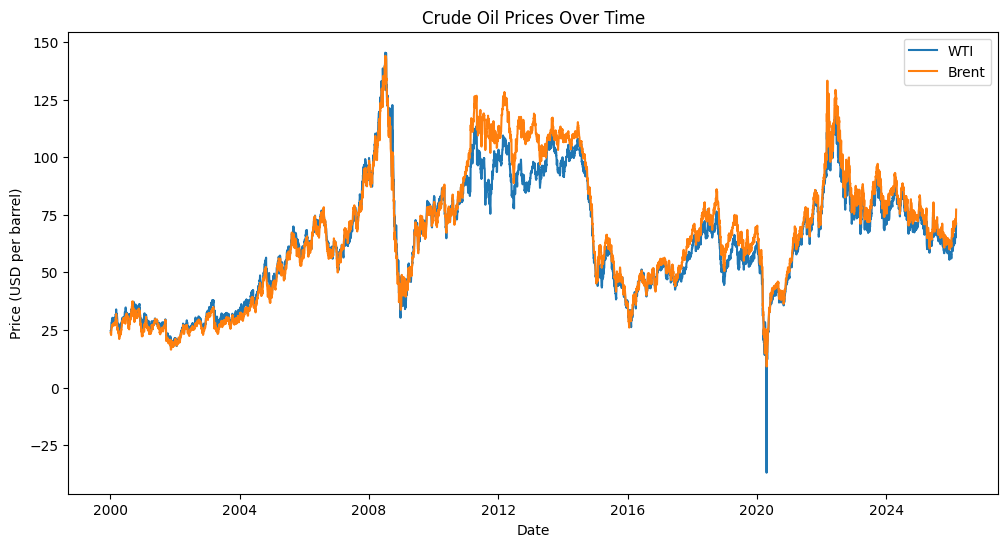

In [20]:
#price time series (WTI vs BRENT)
plt.figure(figsize=(12,6)) #matplotlib
plt.plot(data['date'], data['WTI_price'], label='WTI')
plt.plot(data['date'], data['BRENT_price'], label='Brent')

plt.title('Crude Oil Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD per barrel)')
plt.legend()
plt.show()

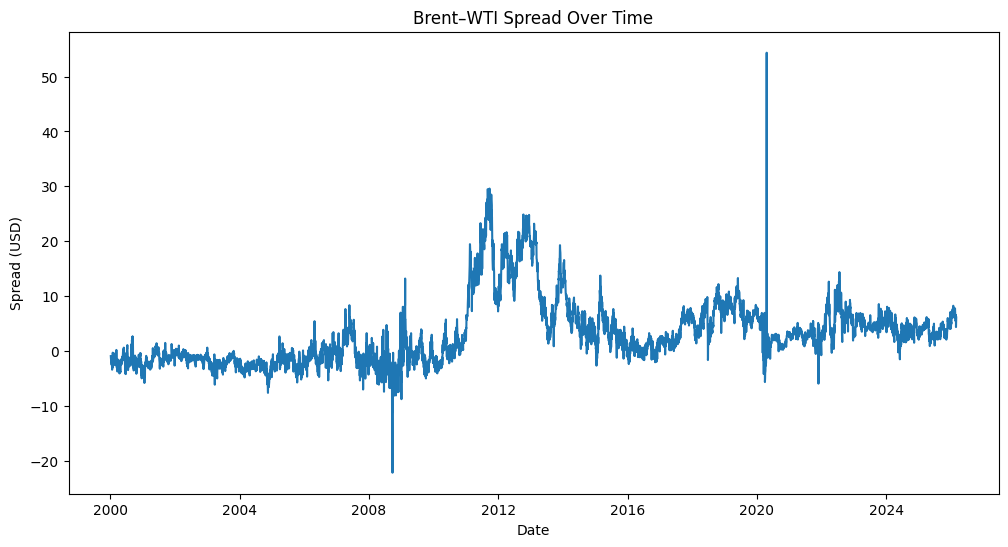

In [21]:
#BRENT-WTI spread
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['brent_wti_spread'])

plt.title('Brent–WTI Spread Over Time')
plt.xlabel('Date')
plt.ylabel('Spread (USD)')
plt.show()

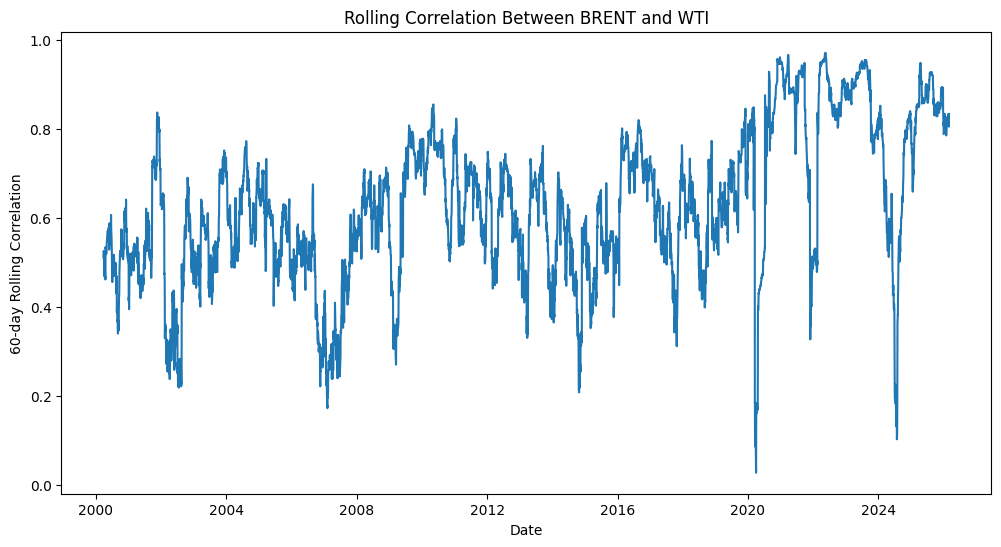

In [22]:
#rolling correlation

plt.figure(figsize=(12,6))
plt.plot(data['date'], data['rolling_corr_60d'])

plt.title('Rolling Correlation Between BRENT and WTI')
plt.xlabel('Date')
plt.ylabel('60-day Rolling Correlation')
plt.show()

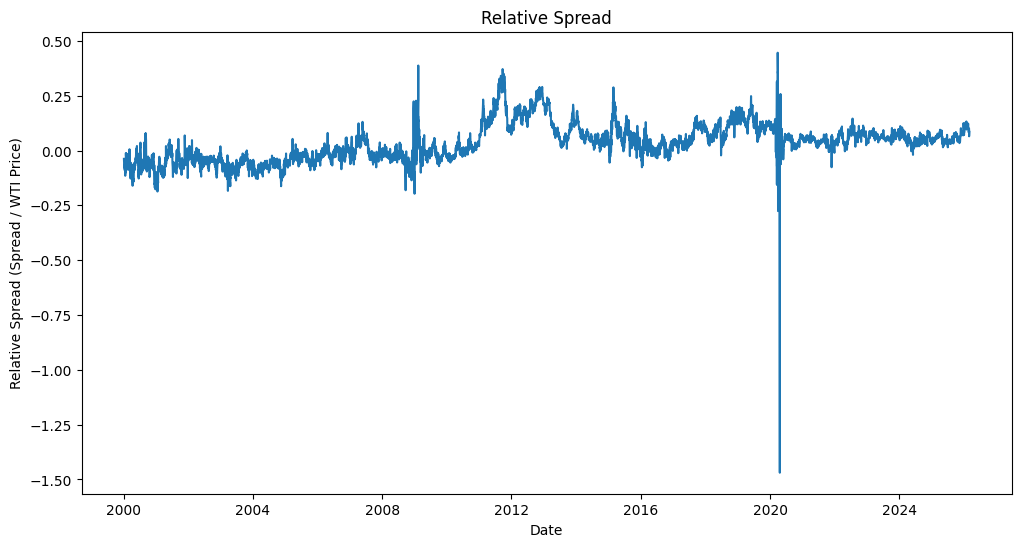

In [23]:
#Relative Spread (Spread / WTI Price)
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['spread_pct'])

plt.title('Relative Spread')
plt.xlabel('Date')
plt.ylabel('Relative Spread (Spread / WTI Price)')
plt.show()

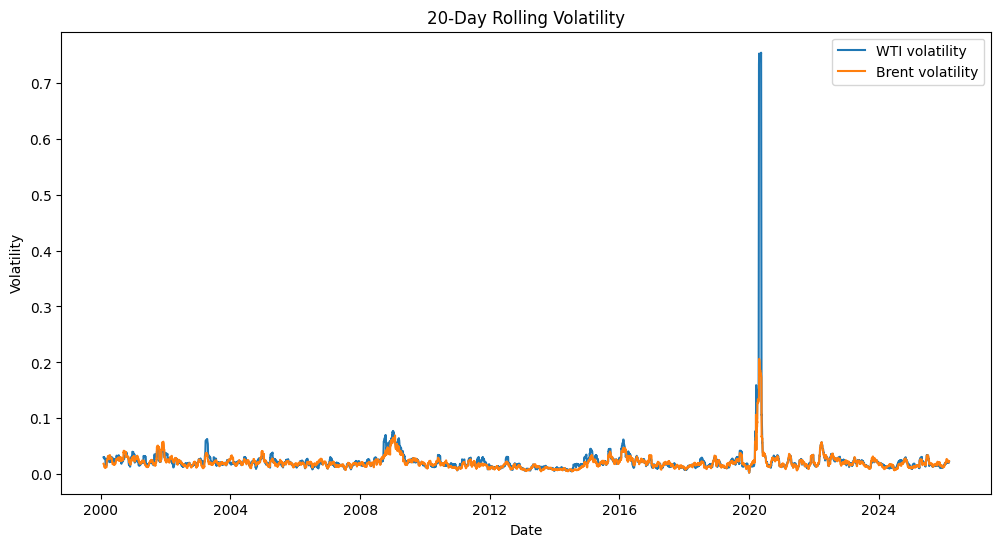

In [24]:
#rolling volatility
plt.figure(figsize=(12,6))
plt.plot(data['date'], data['WTI_volatility_20d'], label='WTI volatility')
plt.plot(data['date'], data['BRENT_volatility_20d'], label='Brent volatility')

plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

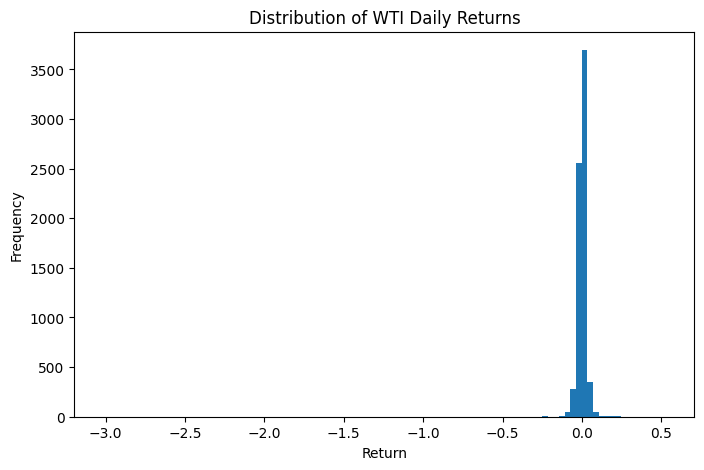

In [25]:
#distrubution of returns; oil proces don't dramatically change day to day so don't expect much here
plt.figure(figsize=(8,5))
plt.hist(data['WTI_return'], bins=100) #i found that bins splits the return values into 100 small intervals (but i know we haven't learned it yet so just removing it won't change anything)

plt.title('Distribution of WTI Daily Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

plt.show()

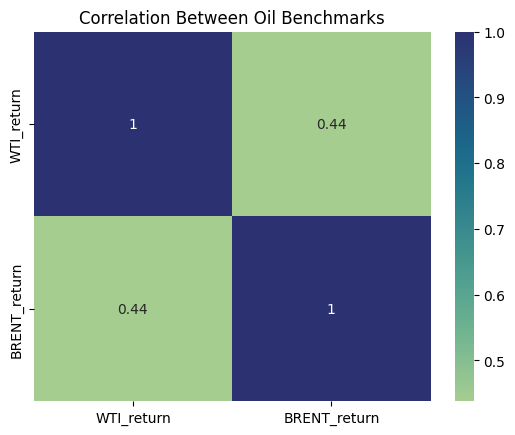

In [26]:
#correlation heatmap
corr = data[['WTI_return','BRENT_return']].corr()

sns.heatmap(corr, annot=True, cmap='crest')
plt.title('Correlation Between Oil Benchmarks')
plt.show()

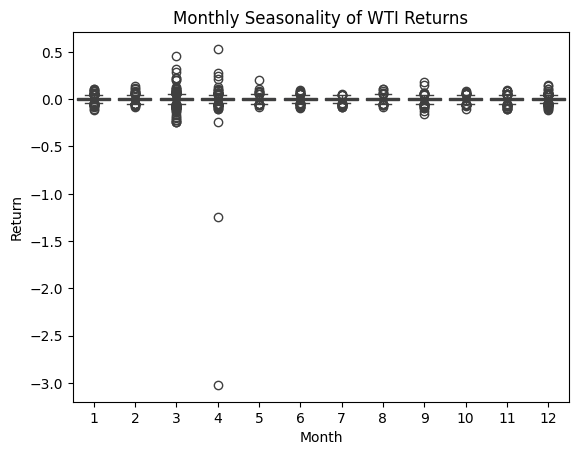

In [27]:
#monthly seasonality using the 'month' feature i engineered
#talk about how oil is traded on monthly averages in paper!!
sns.boxplot(x='month', y='WTI_return', data=data)

plt.title('Monthly Seasonality of WTI Returns')
plt.xlabel('Month')
plt.ylabel('Return')
plt.show()

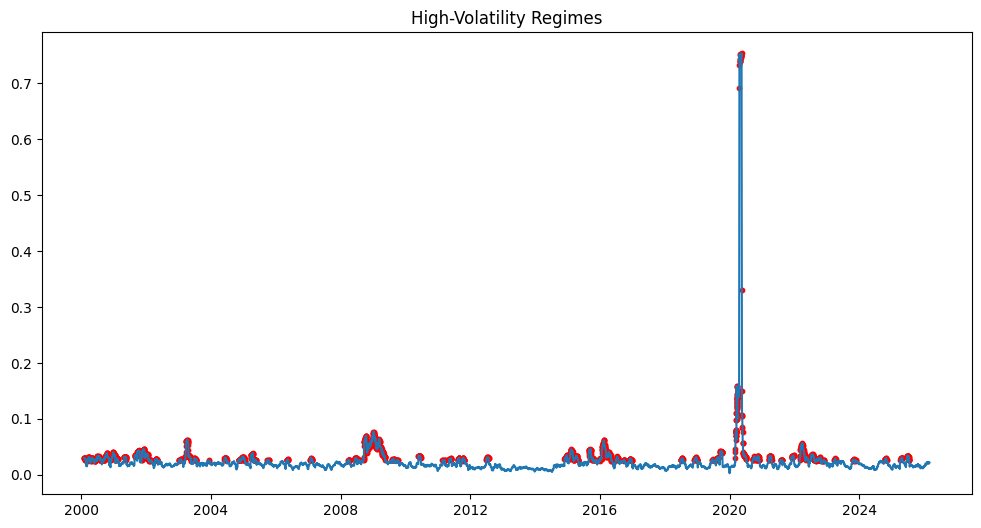

In [28]:
#volatility regimes
plt.figure(figsize=(12,6))

plt.plot(data['date'], data['WTI_volatility_20d'])
plt.scatter(data['date'][data['high_vol_regime']],
            data['WTI_volatility_20d'][data['high_vol_regime']],
            color='red', s=10)

plt.title('High-Volatility Regimes')
plt.show()

In [29]:
#downloading for VS code
data.to_csv("oil_data_clean.csv", index=False)